# Funciones, sus gradientes, espacio de exploración y mínimos globales

Función de Rosenbrock:

$$ f(x,y) = (1-x)^2 + 100(y-x^2)^2 $$

Gradiente:

$$ \nabla f = [2(1-x) - 400x(y-x^2)]\hat{i} + 200(y-x^2)\hat{j} $$

Tiene mínimo global $0$ en $(1,1)$.

Función _Three-Hump Camel_:

$$ f(x,y) = 2x^2 - 1.05x^4 + \tfrac{x^6}{6} + xy + y^2 $$

Gradiente: 

$$ \nabla f = [4x - 4.20x^3 + x^5 + y]\hat{i} + (1 + 2y)\hat{j} $$

Mínimo global $0$ en $(0, 0)$, función definida en $x_i \in [-5, 5]$.

Función _Booth_:

$$ f(x,y) = (x+2y-7)^2 + (2x + y - 5)^2 $$

Gradiente: 

$$ \nabla f = [2(x + 2y - 7) + 4(2x + y - 5)]\hat{i} + [4(x + 2y - 7) + 2(2x + y - 5)]\hat{j} $$

$$ \nabla f = [10x + 8y - 34]\hat{i} + [8x + 10y - 38]\hat{j} $$

Mínimo global $0$ en $(1,3)$, función suele ser evaluada en $x_i \in [-10, 10]$.

Función Styblinski-Tang:

$$ f(x) = \tfrac{1}{2} \sum_{i=1}^d x_i^4 - 16x_i^2 + 5x_i $$

$$ \nabla f = \tfrac{1}{2} \sum_{i=1}^d 4x_i^3 - 32x_i + 5 $$

Yo consideré $ d=2 $ por simplicidad.

Mínimo global $-39.16599d$ en $(-2.903534, \dots, -2.903534)$.

Suele ser evaluada en el hípercubo $x_i \in [-5, 5]$

Vamos a explorar todas en el segmento $x,y \in [-5, 5]$

Importamos las bibliotecas de siempre

In [314]:
import torch
import sklearn
import matplotlib.pyplot as plt
import numpy as np 

In [315]:
DIMS = 2 # Vamos a usar 2 dimensiones para todas las funciones
torch.manual_seed(21) # Para resultados reproducibles

# Codificando las funciones (criterios (pérdida))

In [316]:
def rosenbrock(x, y):
    return (1-x)**2 + 100 * (y - x**2)**2

def three_hump_camel(x, y):
    return 2*x**2 - 1.05 * x**4 + (1 / 6)*x**6 + x*y + y**2

def booth(x, y):
    return (x + 2*y - 7)**2 + (2*x + y - 5)**2

def styblinski_tang(*args):
    xis = torch.stack(list(args))

    return 0.5*(xis**4 - 16*xis**2 + 5*xis).sum()

Ya que queremos comparar los diferentes métodos de descenso haremos que sea más o menos justo y le daremos el mismo punto de pártida a todos los métodos:

In [317]:
puntos_iniciales = np.random.normal(size=(DIMS,))
puntos_iniciales

array([-0.71654408,  2.18383399])

In [318]:
puntos_iniciales2 = np.random.normal(size=(DIMS,))
puntos_iniciales2

array([-0.30835296,  0.42713696])

# Descenso de gradiente

In [ ]:
def gd(punto_partida, criterio, lr=1e-3, n_epocas=5000, verbose=True):
    print(f"Punto de partida: {punto_partida[0]}, {punto_partida[1]}")
    punto_actual = punto_partida.clone().detach().requires_grad_(True)
    historial = [punto_actual.detach()]
    for epoca in range(n_epocas):

        if punto_actual.grad is not None:
            punto_actual.grad.zero_()

        perdida = criterio(*punto_actual)
        perdida.backward()
        #optimizador.paso() no podemos utilizar el paso :c 
        # lo que vamos a hacer es hacer el descenso de gradiente manual con los valores de backward
        with torch.no_grad():
            punto_actual -= punto_actual.grad * lr
        

        historial.append(punto_actual.clone().detach())

        if verbose and (epoca % 5 == 0 or epoca < 5):
            print(f"Pérdida {perdida.item()} en época {epoca + 1} en el punto ({punto_actual[0]}, {punto_actual[1]})")

    print(f"Pérdida final {perdida.item()} en época {epoca + 1} en el punto ({punto_actual[0]}, {punto_actual[1]})")

    return punto_actual, historial

Ahora probaremos las funciones con lr, que parece funcionar más o menos bien 

## Descenso de gradiente en __Rosenbrock__

In [320]:
optimo, historial = gd(torch.tensor(puntos_iniciales, requires_grad=True, dtype=torch.float32), rosenbrock, 1e-3)

Punto de partida: -0.7165440917015076, 2.1838340759277344
Pérdida 281.9697265625 en época 1 en el punto (-1.191876769065857, 1.8497543334960938)
Pérdida 23.224220275878906 en época 2 en el punto (-1.3921067714691162, 1.7639175653457642)
Pérdida 8.751294136047363 en época 3 en el punto (-1.290407657623291, 1.7987263202667236)
Pérdida 7.030178546905518 en época 4 en el punto (-1.3547730445861816, 1.772011399269104)
Pérdida 5.946894645690918 en época 5 en el punto (-1.3157072067260742, 1.7846910953521729)
Pérdida 5.6498565673828125 en época 6 en el punto (-1.339287519454956, 1.7739700078964233)
Pérdida 5.426819324493408 en época 11 en el punto (-1.3265981674194336, 1.7699211835861206)
Pérdida 5.411844730377197 en época 16 en el punto (-1.3245515823364258, 1.7619223594665527)
Pérdida 5.398350715637207 en época 21 en el punto (-1.3215782642364502, 1.7542673349380493)
Pérdida 5.384848594665527 en época 26 en el punto (-1.3186721801757812, 1.7465811967849731)
Pérdida 5.371327877044678 en époc

In [321]:
optimo, historial = gd(torch.tensor(puntos_iniciales2, requires_grad=True, dtype=torch.float32), rosenbrock, 1e-3)

Punto de partida: -0.3083529472351074, 0.42713695764541626
Pérdida 12.73786735534668 en época 1 en el punto (-0.34669235348701477, 0.36072587966918945)
Pérdida 7.599061489105225 en época 2 en el punto (-0.3773549795150757, 0.31261980533599854)
Pérdida 4.794694900512695 en época 3 en el punto (-0.40029406547546387, 0.27857518196105957)
Pérdida 3.361255168914795 en época 4 en el punto (-0.41644176840782166, 0.2549072206020355)
Pérdida 2.6702628135681152 en época 5 en el punto (-0.427182137966156, 0.23861052095890045)
Pérdida 2.351861000061035 en época 6 en el punto (-0.43391817808151245, 0.22738532721996307)
Pérdida 2.091125965118408 en época 11 en el punto (-0.4398326277732849, 0.2041873037815094)
Pérdida 2.0646603107452393 en época 16 en el punto (-0.4332793354988098, 0.19525209069252014)
Pérdida 2.0411250591278076 en época 21 en el punto (-0.4252578914165497, 0.1879526674747467)
Pérdida 2.017522096633911 en época 26 en el punto (-0.4169972240924835, 0.18089184165000916)
Pérdida 1.9938

## Descenso de gradiente en __Three-Hump Camel__

In [322]:
optimo, historial = gd(torch.tensor(puntos_iniciales, requires_grad=True, dtype=torch.float32), three_hump_camel, 1e-3)

Punto de partida: -0.7165440917015076, 2.1838340759277344
Pérdida 3.976950168609619 en época 1 en el punto (-0.7172180414199829, 2.180182933807373)
Pérdida 3.9631810188293457 en época 2 en el punto (-0.717889130115509, 2.176539897918701)
Pérdida 3.9494740962982178 en época 3 en el punto (-0.7185573577880859, 2.1729047298431396)
Pérdida 3.935828447341919 en época 4 en el punto (-0.7192227244377136, 2.1692774295806885)
Pérdida 3.92224383354187 en época 5 en el punto (-0.7198852300643921, 2.1656579971313477)
Pérdida 3.908720016479492 en época 6 en el punto (-0.7205448746681213, 2.1620466709136963)
Pérdida 3.8420112133026123 en época 11 en el punto (-0.7238010764122009, 2.1441075801849365)
Pérdida 3.7767858505249023 en época 16 en el punto (-0.7269876599311829, 2.1263630390167236)
Pérdida 3.713010787963867 en época 21 en el punto (-0.7301058173179626, 2.1088106632232666)
Pérdida 3.650651693344116 en época 26 en el punto (-0.7331566214561462, 2.0914487838745117)
Pérdida 3.589676856994629 en

In [323]:
optimo, historial = gd(torch.tensor(puntos_iniciales2, requires_grad=True, dtype=torch.float32), three_hump_camel, 1e-3)

Punto de partida: -0.3083529472351074, 0.42713695764541626
Pérdida 0.23155085742473602 en época 1 en el punto (-0.3076670169830322, 0.42659103870391846)
Pérdida 0.23078292608261108 en época 2 en el punto (-0.30698248744010925, 0.4260455369949341)
Pérdida 0.23001736402511597 en época 3 en el punto (-0.3062993884086609, 0.42550042271614075)
Pérdida 0.22925418615341187 en época 4 en el punto (-0.30561769008636475, 0.42495572566986084)
Pérdida 0.2284933626651764 en época 5 en el punto (-0.3049373924732208, 0.42441144585609436)
Pérdida 0.22773490846157074 en época 6 en el punto (-0.3042584955692291, 0.4238675534725189)
Pérdida 0.22397784888744354 en época 11 en el punto (-0.3008851706981659, 0.421154260635376)
Pérdida 0.22027918696403503 en época 16 en el punto (-0.29754701256752014, 0.4184512794017792)
Pérdida 0.21663837134838104 en época 21 en el punto (-0.29424387216567993, 0.4157586395740509)
Pérdida 0.2130548357963562 en época 26 en el punto (-0.29097574949264526, 0.4130764305591583)
P

## Descenso de gradiente en __Booth__

In [324]:
optimo, historial = gd(torch.tensor(puntos_iniciales, requires_grad=True, dtype=torch.float32), booth, 1e-3)

Punto de partida: -0.7165440917015076, 2.1838340759277344
Pérdida 29.271133422851562 en época 1 en el punto (-0.692849338054657, 2.205728054046631)
Pérdida 28.239696502685547 en época 2 en el punto (-0.6695666909217834, 2.2272136211395264)
Pérdida 27.245006561279297 en época 3 en el punto (-0.6466887593269348, 2.248297929763794)
Pérdida 26.285755157470703 en época 4 en el punto (-0.6242082715034485, 2.2689883708953857)
Pérdida 25.360675811767578 en época 5 en el punto (-0.6021180748939514, 2.289292097091675)
Pérdida 24.468544006347656 en época 6 en el punto (-0.5804112553596497, 2.309216022491455)
Pérdida 20.462478637695312 en época 11 en el punto (-0.4773908257484436, 2.4033758640289307)
Pérdida 17.120664596557617 en época 16 en el punto (-0.382973849773407, 2.4890201091766357)
Pérdida 14.332788467407227 en época 21 en el punto (-0.29641684889793396, 2.56689190864563)
Pérdida 12.006868362426758 en época 26 en el punto (-0.2170407474040985, 2.637669324874878)
Pérdida 10.066193580627441

In [325]:
optimo, historial = gd(torch.tensor(puntos_iniciales2, requires_grad=True, dtype=torch.float32), booth, 1e-3)

Punto de partida: -0.3083529472351074, 0.42713695764541626
Pérdida 68.58676147460938 en época 1 en el punto (-0.2746865153312683, 0.4633324146270752)
Pérdida 66.1651840209961 en época 2 en el punto (-0.24164630472660065, 0.49889659881591797)
Pérdida 63.82990646362305 en época 3 en el punto (-0.2092210054397583, 0.5338407754898071)
Pérdida 61.57783508300781 en época 4 en el punto (-0.17739951610565186, 0.5681761503219604)
Pérdida 59.40601348876953 en época 5 en el punto (-0.14617092907428741, 0.601913571357727)
Pérdida 57.311561584472656 en época 6 en el punto (-0.1155245304107666, 0.6350638270378113)
Pérdida 47.90684509277344 en época 11 en el punto (0.029336320236325264, 0.7923689484596252)
Pérdida 40.06195831298828 en época 16 en el punto (0.16114243865013123, 0.9364953637123108)
Pérdida 33.517860412597656 en época 21 en el punto (0.281031996011734, 1.068582534790039)
Pérdida 28.058555603027344 en época 26 en el punto (0.39004427194595337, 1.1896708011627197)
Pérdida 23.5038833618164

## Descenso de gradiente en __Styblinski-Tang__

In [326]:
optimo, historial = gd(torch.tensor(puntos_iniciales, requires_grad=True, dtype=torch.float32), styblinski_tang, 1e-3)

Punto de partida: -0.7165440917015076, 2.1838340759277344
Pérdida -27.088191986083984 en época 1 en el punto (-0.7297729849815369, 2.1954455375671387)
Pérdida -27.39829444885254 en época 2 en el punto (-0.7431720495223999, 2.206908702850342)
Pérdida -27.709522247314453 en época 3 en el punto (-0.7567418813705444, 2.21822190284729)
Pérdida -28.021963119506836 en época 4 en el punto (-0.7704830169677734, 2.229383945465088)
Pérdida -28.33570671081543 en época 5 en el punto (-0.7843959331512451, 2.2403934001922607)
Pérdida -28.650840759277344 en época 6 en el punto (-0.7984810471534729, 2.251249074935913)
Pérdida -30.250568389892578 en época 11 en el punto (-0.871494710445404, 2.3031885623931885)
Pérdida -31.89897346496582 en época 16 en el punto (-0.9488075375556946, 2.3511829376220703)
Pérdida -33.60708999633789 en época 21 en el punto (-1.030335783958435, 2.3952295780181885)
Pérdida -35.38372802734375 en época 26 en el punto (-1.1159031391143799, 2.4353935718536377)
Pérdida -37.23381805

In [327]:
optimo, historial = gd(torch.tensor(puntos_iniciales2, requires_grad=True, dtype=torch.float32), styblinski_tang, 1e-3)

Punto de partida: -0.3083529472351074, 0.42713695764541626
Pérdida -1.9020966291427612 en época 1 en el punto (-0.31572794914245605, 0.4313153028488159)
Pérdida -1.9744952917099 en época 2 en el punto (-0.32321664690971375, 0.4355558753013611)
Pérdida -2.049123764038086 en época 3 en el punto (-0.33082059025764465, 0.4398595094680786)
Pérdida -2.126046657562256 en época 4 en el punto (-0.33854129910469055, 0.44422706961631775)
Pérdida -2.2053298950195312 en época 5 en el punto (-0.346380352973938, 0.44865939021110535)
Pérdida -2.2870419025421143 en época 6 en el punto (-0.3543393313884735, 0.45315730571746826)
Pérdida -2.7345144748687744 en época 11 en el punto (-0.39598801732063293, 0.4766616225242615)
Pérdida -3.2538185119628906 en época 16 en el punto (-0.4408721327781677, 0.5019386410713196)
Pérdida -3.8553056716918945 en época 21 en el punto (-0.48919010162353516, 0.5291023254394531)
Pérdida -4.5503644943237305 en época 26 en el punto (-0.5411365628242493, 0.5582696795463562)
Pérd

Pérdida -21.857006072998047 en época 81 en el punto (-1.37991464138031, 1.0424922704696655)
Pérdida -24.469820022583008 en época 86 en el punto (-1.4773247241973877, 1.1031743288040161)
Pérdida -27.21340560913086 en época 91 en el punto (-1.5762364864349365, 1.1665645837783813)
Pérdida -30.053539276123047 en época 96 en el punto (-1.6757770776748657, 1.2325032949447632)
Pérdida -32.94972229003906 en época 101 en el punto (-1.774990200996399, 1.3007736206054688)
Pérdida -35.85726547241211 en época 106 en el punto (-1.8728715181350708, 1.3710978031158447)
Pérdida -38.72998046875 en época 111 en el punto (-1.968411922454834, 1.4431359767913818)
Pérdida -41.523155212402344 en época 116 en el punto (-2.0606446266174316, 1.516487717628479)
Pérdida -44.19637680053711 en época 121 en el punto (-2.1486916542053223, 1.5906972885131836)
Pérdida -46.71576690673828 en época 126 en el punto (-2.231804609298706, 1.665260910987854)
Pérdida -49.05548095703125 en época 131 en el punto (-2.30939745903015

# Descenso de gradiente con momento

In [ ]:
# este es casi lo mismo, solo necesita unos ajustes
def gd_con_momento(punto_partida, criterio, lr=1e-03, momento=0.9, n_epocas=5000, verbose=True):
    print(f"Punto de partida: {punto_partida[0]}, {punto_partida[1]}")
    punto_actual = punto_partida.clone().detach().requires_grad_(True)
    cambio = 0
    historial = [punto_actual.detach()]
    for epoca in range(n_epocas):

        if punto_actual.grad is not None:
            punto_actual.grad.zero_()

        perdida = criterio(*punto_actual)
        perdida.backward()
        with torch.no_grad():

            nuevo_cambio = lr*punto_actual.grad + momento*cambio
            punto_actual -= nuevo_cambio
            cambio = nuevo_cambio
        

        historial.append(punto_actual.clone().detach())

        if verbose and (epoca % 5 == 0 or epoca < 5):
            print(f"Pérdida {perdida.item()} en época {epoca + 1} en el punto ({punto_actual[0]}, {punto_actual[1]})")

    print(f"Pérdida final {perdida.item()} en época {epoca + 1} en el punto ({punto_actual[0]}, {punto_actual[1]})")

    return punto_actual, historial

## Descenso de gradiente con momento en __Rosenbrock__

In [329]:
optimo, historial = gd_con_momento(torch.tensor(puntos_iniciales, requires_grad=True, dtype=torch.float32), rosenbrock, 0.9, 1e-5)

Punto de partida: -0.7165440917015076, 2.1838340759277344
Pérdida 281.9697265625 en época 1 en el punto (-428.51593017578125, -298.4879150390625)
Pérdida 3382818373632.0 en época 2 en el punto (28373231616.0, 33106094.0)
Pérdida inf en época 3 en el punto (-8.222972764081744e+33, 1.4490723614232152e+23)
Pérdida inf en época 4 en el punto (inf, inf)
Pérdida nan en época 5 en el punto (nan, nan)
Pérdida nan en época 6 en el punto (nan, nan)
Pérdida nan en época 11 en el punto (nan, nan)
Pérdida nan en época 16 en el punto (nan, nan)
Pérdida nan en época 21 en el punto (nan, nan)
Pérdida nan en época 26 en el punto (nan, nan)
Pérdida nan en época 31 en el punto (nan, nan)
Pérdida nan en época 36 en el punto (nan, nan)
Pérdida nan en época 41 en el punto (nan, nan)
Pérdida nan en época 46 en el punto (nan, nan)
Pérdida nan en época 51 en el punto (nan, nan)
Pérdida nan en época 56 en el punto (nan, nan)
Pérdida nan en época 61 en el punto (nan, nan)
Pérdida nan en época 66 en el punto (nan

No parece converger, si aumentamos considerablemente la fricción encontramos que aun así no converge, el momento explota y no hay forma de contrarrestarlo

In [330]:
optimo, historial = gd_con_momento(torch.tensor(puntos_iniciales, requires_grad=True, dtype=torch.float32), rosenbrock, 0.15, 1e-5)

Punto de partida: -0.7165440917015076, 2.1838340759277344
Pérdida 281.9697265625 en época 1 en el punto (-72.01644134521484, -47.928131103515625)
Pérdida 2739790848.0 en época 2 en el punto (22617272.0, 156980.96875)
Pérdida 2.616741939005782e+31 en época 3 en el punto (-6.941797304737116e+23, 1.5346230607478784e+16)
Pérdida inf en época 4 en el punto (inf, inf)
Pérdida nan en época 5 en el punto (nan, nan)
Pérdida nan en época 6 en el punto (nan, nan)
Pérdida nan en época 11 en el punto (nan, nan)
Pérdida nan en época 16 en el punto (nan, nan)
Pérdida nan en época 21 en el punto (nan, nan)
Pérdida nan en época 26 en el punto (nan, nan)
Pérdida nan en época 31 en el punto (nan, nan)
Pérdida nan en época 36 en el punto (nan, nan)
Pérdida nan en época 41 en el punto (nan, nan)
Pérdida nan en época 46 en el punto (nan, nan)
Pérdida nan en época 51 en el punto (nan, nan)
Pérdida nan en época 56 en el punto (nan, nan)
Pérdida nan en época 61 en el punto (nan, nan)
Pérdida nan en época 66 en

In [331]:
optimo, historial = gd_con_momento(torch.tensor(puntos_iniciales2, requires_grad=True, dtype=torch.float32), rosenbrock, 0.9, 1e-5)

Punto de partida: -0.3083529472351074, 0.42713695764541626
Pérdida 12.73786735534668 en época 1 en el punto (-34.813812255859375, -59.34284210205078)
Pérdida 161632928.0 en época 2 en el punto (15933754.0, 228782.640625)
Pérdida 6.445734364522715e+30 en época 3 en el punto (-1.4563200043035426e+24, 4.569921223865139e+16)
Pérdida inf en época 4 en el punto (inf, inf)
Pérdida nan en época 5 en el punto (nan, nan)
Pérdida nan en época 6 en el punto (nan, nan)
Pérdida nan en época 11 en el punto (nan, nan)
Pérdida nan en época 16 en el punto (nan, nan)
Pérdida nan en época 21 en el punto (nan, nan)
Pérdida nan en época 26 en el punto (nan, nan)
Pérdida nan en época 31 en el punto (nan, nan)
Pérdida nan en época 36 en el punto (nan, nan)
Pérdida nan en época 41 en el punto (nan, nan)
Pérdida nan en época 46 en el punto (nan, nan)
Pérdida nan en época 51 en el punto (nan, nan)
Pérdida nan en época 56 en el punto (nan, nan)
Pérdida nan en época 61 en el punto (nan, nan)
Pérdida nan en época 6

In [332]:
optimo, historial = gd_con_momento(torch.tensor(puntos_iniciales2, requires_grad=True, dtype=torch.float32), rosenbrock, 0.05, 1e-5)

Punto de partida: -0.3083529472351074, 0.42713695764541626
Pérdida 12.73786735534668 en época 1 en el punto (-2.22532320022583, -2.8934175968170166)
Pérdida 6165.56005859375 en época 2 en el punto (347.2718200683594, 75.56136322021484)
Pérdida 1452559171584.0 en época 3 en el punto (-837078720.0, 1205297.125)
Pérdida 4.909815627020929e+37 en época 4 en el punto (1.1730834121871348e+28, 7.007007833665307e+18)
Pérdida inf en época 5 en el punto (-inf, inf)
Pérdida nan en época 6 en el punto (nan, nan)
Pérdida nan en época 11 en el punto (nan, nan)
Pérdida nan en época 16 en el punto (nan, nan)
Pérdida nan en época 21 en el punto (nan, nan)
Pérdida nan en época 26 en el punto (nan, nan)
Pérdida nan en época 31 en el punto (nan, nan)
Pérdida nan en época 36 en el punto (nan, nan)
Pérdida nan en época 41 en el punto (nan, nan)
Pérdida nan en época 46 en el punto (nan, nan)
Pérdida nan en época 51 en el punto (nan, nan)
Pérdida nan en época 56 en el punto (nan, nan)
Pérdida nan en época 61 e

## Descenso de gradiente con momento en __Three-Hump Camel__

In [333]:
optimo, historial = gd_con_momento(torch.tensor(puntos_iniciales, requires_grad=True, dtype=torch.float32), three_hump_camel, 0.9, 1e-3)

Punto de partida: -0.7165440917015076, 2.1838340759277344
Pérdida 3.976950168609619 en época 1 en el punto (-1.3230912685394287, -1.102177381515503)
Pérdida 3.8505988121032715 en época 2 en el punto (-0.6745620369911194, 2.0692379474639893)
Pérdida 3.5942788124084473 en época 3 en el punto (-1.1423652172088623, -1.0451130867004395)
Pérdida 3.4783935546875 en época 4 en el punto (0.02604210376739502, 1.8611047267913818)
Pérdida 3.5135338306427 en época 5 en el punto (-1.7414685487747192, -1.5094151496887207)
Pérdida 5.963963508605957 en época 6 en el punto (0.33613121509552, 2.7714834213256836)
Pérdida nan en época 11 en el punto (nan, -inf)
Pérdida nan en época 16 en el punto (nan, nan)
Pérdida nan en época 21 en el punto (nan, nan)
Pérdida nan en época 26 en el punto (nan, nan)
Pérdida nan en época 31 en el punto (nan, nan)
Pérdida nan en época 36 en el punto (nan, nan)
Pérdida nan en época 41 en el punto (nan, nan)
Pérdida nan en época 46 en el punto (nan, nan)
Pérdida nan en época 5

In [334]:
optimo, historial = gd_con_momento(torch.tensor(puntos_iniciales, requires_grad=True, dtype=torch.float32), three_hump_camel, 0.1, 1e-3)

Punto de partida: -0.7165440917015076, 2.1838340759277344
Pérdida 3.976950168609619 en época 1 en el punto (-0.7839382290840149, 1.8187216520309448)
Pérdida 2.7532191276550293 en época 2 en el punto (-0.8250405788421631, 1.533005952835083)
Pérdida 2.012755870819092 en época 3 en el punto (-0.8460098505020142, 1.3086230754852295)
Pérdida 1.5600733757019043 en época 4 en el punto (-0.8494674563407898, 1.1312750577926636)
Pérdida 1.2778798341751099 en época 5 en el punto (-0.8360276818275452, 0.9897894263267517)
Pérdida 1.0940380096435547 en época 6 en el punto (-0.80516117811203, 0.8752928376197815)
Pérdida 0.48237186670303345 en época 11 en el punto (-0.4146886169910431, 0.5016691088676453)
Pérdida 0.08592760562896729 en época 16 en el punto (-0.12382093071937561, 0.24576523900032043)
Pérdida 0.015071487054228783 en época 21 en el punto (-0.04570974037051201, 0.10661733150482178)
Pérdida 0.0026774639263749123 en época 26 en el punto (-0.018798228353261948, 0.04512961208820343)
Pérdida 0

In [335]:
optimo, historial = gd_con_momento(torch.tensor(puntos_iniciales2, requires_grad=True, dtype=torch.float32), three_hump_camel, 0.9, 1e-3)

Punto de partida: -0.3083529472351074, 0.42713695764541626
Pérdida 0.23155085742473602 en época 1 en el punto (0.3089786767959595, -0.06419190764427185)
Pérdida 0.16579751670360565 en época 2 en el punto (-0.6359883546829224, -0.2272186130285263)
Pérdida 0.8443428874015808 en época 3 en el punto (0.9783799648284912, 0.7540013790130615)
Pérdida 2.4047563076019287 en época 4 en el punto (-0.48751044273376465, -1.4827616214752197)
Pérdida 3.3397045135498047 en época 5 en el punto (2.187361001968384, 1.6227316856384277)
Pérdida 9.969927787780762 en época 6 en el punto (-12.650773048400879, -3.263704299926758)
Pérdida nan en época 11 en el punto (nan, nan)
Pérdida nan en época 16 en el punto (nan, nan)
Pérdida nan en época 21 en el punto (nan, nan)
Pérdida nan en época 26 en el punto (nan, nan)
Pérdida nan en época 31 en el punto (nan, nan)
Pérdida nan en época 36 en el punto (nan, nan)
Pérdida nan en época 41 en el punto (nan, nan)
Pérdida nan en época 46 en el punto (nan, nan)
Pérdida nan

In [336]:
optimo, historial = gd_con_momento(torch.tensor(puntos_iniciales2, requires_grad=True, dtype=torch.float32), three_hump_camel, 0.1, 1e-3)

Punto de partida: -0.3083529472351074, 0.42713695764541626
Pérdida 0.23155085742473602 en época 1 en el punto (-0.23976054787635803, 0.3725448548793793)
Pérdida 0.16100023686885834 en época 2 en el punto (-0.18675170838832855, 0.3219573497772217)
Pérdida 0.11201275885105133 en época 3 en el punto (-0.14690658450126648, 0.27619045972824097)
Pérdida 0.07838268578052521 en época 4 en el punto (-0.11704790592193604, 0.23559725284576416)
Pérdida 0.055133670568466187 en época 5 en el punto (-0.09442991763353348, 0.2001419961452484)
Pérdida 0.03890807181596756 en época 6 en el punto (-0.07700243592262268, 0.16952113807201385)
Pérdida 0.006900902837514877 en época 11 en el punto (-0.03043198212981224, 0.07235376536846161)
Pérdida 0.001225541578605771 en época 16 en el punto (-0.01268373429775238, 0.0305454321205616)
Pérdida 0.00021754240151494741 en época 21 en el punto (-0.005334259942173958, 0.012872803024947643)
Pérdida 3.861134246108122e-05 en época 26 en el punto (-0.00224663014523685, 0.

A este no le fue __tan__ mal, aunque terminó alejandose del óptimo

## Descenso de gradiente con momento en __Booth__

In [337]:
optimo, historial = gd_con_momento(torch.tensor(puntos_iniciales, requires_grad=True, dtype=torch.float32), booth, 0.9, 1e-5)

Punto de partida: -0.7165440917015076, 2.1838340759277344
Pérdida 29.271133422851562 en época 1 en el punto (20.608747482299805, 21.888444900512695)
Pérdida 6669.41162109375 en época 2 en el punto (-291.8665771484375, -289.29034423828125)
Pérdida 1540839.0 en época 3 en el punto (4448.419921875, 4449.958984375)
Pérdida 355994880.0 en época 4 en el punto (-67596.4140625, -67594.046875)
Pérdida 82248941568.0 en época 5 en el punto (1027478.1875, 1027479.9375)
Pérdida 19002764034048.0 en época 6 en el punto (-15617640.0, -15617636.0)
Pérdida 1.2509777091579602e+25 en época 11 en el punto (12671611043840.0, 12671611043840.0)
Pérdida 8.235349802485003e+36 en época 16 en el punto (-1.0281300134868287e+19, -1.0281300134868287e+19)
Pérdida inf en época 21 en el punto (8.34188803022429e+24, 8.34188803022429e+24)
Pérdida inf en época 26 en el punto (-6.768317481136675e+30, -6.768317481136675e+30)
Pérdida inf en época 31 en el punto (5.49157775639331e+36, 5.49157775639331e+36)
Pérdida nan en époc

In [338]:
optimo, historial = gd_con_momento(torch.tensor(puntos_iniciales, requires_grad=True, dtype=torch.float32), booth, 0.15, 1e-5)

Punto de partida: -0.7165440917015076, 2.1838340759277344
Pérdida 29.271133422851562 en época 1 en el punto (2.8376712799072266, 5.467936038970947)
Pérdida 83.62075805664062 en época 2 en el punto (-2.8803234100341797, -0.43914079666137695)
Pérdida 241.1828155517578 en época 3 en el punto (7.067073822021484, 9.375898361206055)
Pérdida 696.771728515625 en época 4 en el punto (-9.684516906738281, -7.468341827392578)
Pérdida 2013.518798828125 en época 5 en el punto (18.904102325439453, 21.055423736572266)
Pérdida 5818.9052734375 en época 6 en el punto (-29.618274688720703, -27.512348175048828)
Pérdida 1172976.5 en época 11 en el punto (434.9547119140625, 436.9725036621094)
Pérdida 236449408.0 en época 16 en el punto (-6160.37841796875, -6158.3759765625)
Pérdida 47663656960.0 en época 21 en el punto (87479.6953125, 87481.703125)
Pérdida 9608068333568.0 en época 26 en el punto (-1242013.5, -1242011.5)
Pérdida 1936800201310208.0 en época 31 en el punto (17634010.0, 17634012.0)
Pérdida 3.9042

In [339]:
optimo, historial = gd_con_momento(torch.tensor(puntos_iniciales2, requires_grad=True, dtype=torch.float32), booth, 0.9, 1e-5)

Punto de partida: -0.3083529472351074, 0.42713695764541626
Pérdida 68.58676147460938 en época 1 en el punto (29.991437911987305, 33.00304412841797)
Pérdida 15662.08203125 en época 2 en el punto (-446.9530944824219, -445.7623291015625)
Pérdida 3618443.75 en época 3 en el punto (6815.70849609375, 6818.35595703125)
Pérdida 836003968.0 en época 4 en el punto (-103587.15625, -103585.671875)
Pérdida 193150074880.0 en época 5 en el punto (1574543.625, 1574546.0)
Pérdida 44625326768128.0 en época 6 en el punto (-23933030.0, -23933030.0)
Pérdida 2.937744067324846e+25 en época 11 en el punto (19418425851904.0, 19418425851904.0)
Pérdida 1.933956277846692e+37 en época 16 en el punto (-1.5755432079006892e+19, -1.5755432079006892e+19)
Pérdida inf en época 21 en el punto (1.2783410328561487e+25, 1.2783410328561487e+25)
Pérdida inf en época 26 en el punto (-1.03720153371583e+31, -1.03720153371583e+31)
Pérdida inf en época 31 en el punto (8.415491826331636e+36, 8.415491826331636e+36)
Pérdida nan en épo

In [340]:
optimo, historial = gd_con_momento(torch.tensor(puntos_iniciales2, requires_grad=True, dtype=torch.float32), booth, 0.15, 1e-5)

Punto de partida: -0.3083529472351074, 0.42713695764541626
Pérdida 68.58676147460938 en época 1 en el punto (4.741612434387207, 5.856455326080322)
Pérdida 196.29698181152344 en época 2 en el punto (-4.298501968383789, -2.9181084632873535)
Pérdida 566.3475341796875 en época 3 en el punto (10.750890731811523, 12.317171096801758)
Pérdida 1636.25341796875 en época 4 en el punto (-15.055902481079102, -13.359502792358398)
Pérdida 4728.45947265625 en época 5 en el punto (28.65909767150879, 30.446577072143555)
Pérdida 13664.8818359375 en época 6 en el punto (-45.76500701904297, -43.91377258300781)
Pérdida 2754572.5 en época 11 en el punto (666.0340576171875, 668.0090942382812)
Pérdida 555268288.0 en época 16 en el punto (-9440.9130859375, -9438.91796875)
Pérdida 111931408384.0 en época 21 en el punto (134056.484375, 134058.484375)
Pérdida 22563195453440.0 en época 26 en el punto (-1903306.5, -1903304.5)
Pérdida 4548305941954560.0 en época 31 en el punto (27022992.0, 27022996.0)
Pérdida 9.16849

## Descenso de gradiente con momento en __Styblinski-Tang__

In [341]:
optimo, historial = gd_con_momento(torch.tensor(puntos_iniciales, requires_grad=True, dtype=torch.float32), styblinski_tang, 0.9, 1e-5)

Punto de partida: -0.7165440917015076, 2.1838340759277344
Pérdida -27.088191986083984 en época 1 en el punto (-12.622560501098633, 12.63405990600586)
Pérdida 22880.498046875 en época 2 en el punto (3423.41552734375, -3437.640869140625)
Pérdida 138501538447360.0 en época 3 en el punto (-72218927104.0, 73122947072.0)
Pérdida inf en época 4 en el punto (6.779936080332729e+32, -7.037745604351679e+32)
Pérdida nan en época 5 en el punto (-inf, inf)
Pérdida nan en época 6 en el punto (nan, nan)
Pérdida nan en época 11 en el punto (nan, nan)
Pérdida nan en época 16 en el punto (nan, nan)
Pérdida nan en época 21 en el punto (nan, nan)
Pérdida nan en época 26 en el punto (nan, nan)
Pérdida nan en época 31 en el punto (nan, nan)
Pérdida nan en época 36 en el punto (nan, nan)
Pérdida nan en época 41 en el punto (nan, nan)
Pérdida nan en época 46 en el punto (nan, nan)
Pérdida nan en época 51 en el punto (nan, nan)
Pérdida nan en época 56 en el punto (nan, nan)
Pérdida nan en época 61 en el punto (

In [342]:
optimo, historial = gd_con_momento(torch.tensor(puntos_iniciales, requires_grad=True, dtype=torch.float32), styblinski_tang, 0.1, 1e-5)

Punto de partida: -0.7165440917015076, 2.1838340759277344
Pérdida -27.088191986083984 en época 1 en el punto (-2.0394349098205566, 3.344970226287842)
Pérdida -48.276344299316406 en época 2 en el punto (-3.8560218811035156, 0.9616765975952148)
Pérdida -22.615863800048828 en época 3 en el punto (1.1912899017333984, 2.0724594593048096)
Pérdida -27.323789596557617 en época 4 en el punto (2.509275197982788, 3.358126401901245)
Pérdida -42.51106643676758 en época 5 en el punto (3.114217519760132, 0.907214879989624)
Pérdida -26.74983787536621 en época 6 en el punto (1.8064167499542236, 1.9593995809555054)
Pérdida -42.727081298828125 en época 11 en el punto (2.319139003753662, 0.912423849105835)
Pérdida -43.186302185058594 en época 16 en el punto (1.8694212436676025, 3.3581700325012207)
Pérdida -25.77422523498535 en época 21 en el punto (1.4092689752578735, 2.1154870986938477)
Pérdida -35.47548294067383 en época 26 en el punto (3.2929911613464355, 0.9688766002655029)
Pérdida -32.652366638183594

In [343]:
optimo, historial = gd_con_momento(torch.tensor(puntos_iniciales2, requires_grad=True, dtype=torch.float32), styblinski_tang, 0.9, 1e-5)

Punto de partida: -0.3083529472351074, 0.42713695764541626
Pérdida -1.9020966291427612 en época 1 en el punto (-6.94586181640625, 4.187635898590088)
Pérdida 784.40478515625 en época 2 en el punto (493.9691467285156, -69.94447326660156)
Pérdida 29779324928.0 en época 3 en el punto (-216948544.0, 614852.5)
Pérdida 1.1076357860614929e+33 en época 4 en el punto (1.8379881543971382e+25, -4.183938955424563e+17)
Pérdida nan en época 5 en el punto (-inf, inf)
Pérdida nan en época 6 en el punto (nan, nan)
Pérdida nan en época 11 en el punto (nan, nan)
Pérdida nan en época 16 en el punto (nan, nan)
Pérdida nan en época 21 en el punto (nan, nan)
Pérdida nan en época 26 en el punto (nan, nan)
Pérdida nan en época 31 en el punto (nan, nan)
Pérdida nan en época 36 en el punto (nan, nan)
Pérdida nan en época 41 en el punto (nan, nan)
Pérdida nan en época 46 en el punto (nan, nan)
Pérdida nan en época 51 en el punto (nan, nan)


Pérdida nan en época 56 en el punto (nan, nan)
Pérdida nan en época 61 en el punto (nan, nan)
Pérdida nan en época 66 en el punto (nan, nan)
Pérdida nan en época 71 en el punto (nan, nan)
Pérdida nan en época 76 en el punto (nan, nan)
Pérdida nan en época 81 en el punto (nan, nan)
Pérdida nan en época 86 en el punto (nan, nan)
Pérdida nan en época 91 en el punto (nan, nan)
Pérdida nan en época 96 en el punto (nan, nan)
Pérdida nan en época 101 en el punto (nan, nan)
Pérdida nan en época 106 en el punto (nan, nan)
Pérdida nan en época 111 en el punto (nan, nan)
Pérdida nan en época 116 en el punto (nan, nan)
Pérdida nan en época 121 en el punto (nan, nan)
Pérdida nan en época 126 en el punto (nan, nan)
Pérdida nan en época 131 en el punto (nan, nan)
Pérdida nan en época 136 en el punto (nan, nan)
Pérdida nan en época 141 en el punto (nan, nan)
Pérdida nan en época 146 en el punto (nan, nan)
Pérdida nan en época 151 en el punto (nan, nan)
Pérdida nan en época 156 en el punto (nan, nan)
P

In [344]:
optimo, historial = gd_con_momento(torch.tensor(puntos_iniciales2, requires_grad=True, dtype=torch.float32), styblinski_tang, 0.15, 1e-5)

Punto de partida: -0.3083529472351074, 0.42713695764541626
Pérdida -1.9020966291427612 en época 1 en el punto (-1.4146045446395874, 1.053886890411377)
Pérdida -23.17704963684082 en época 2 en el punto (-4.335434436798096, 2.8570632934570312)
Pérdida -9.405953407287598 en época 3 en el punto (9.331130981445312, 2.342533826828003)
Pérdida 3094.37353515625 en época 4 en el punto (-212.3875274658203, 3.7332382202148438)
Pérdida 1017025280.0 en época 5 en el punto (2873419.75, -3.29109525680542)
Pérdida 3.4085234228299874e+25 en época 6 en el punto (-7.11735262160565e+18, -0.870734453201294)
Pérdida nan en época 11 en el punto (nan, -1033.3519287109375)
Pérdida nan en época 16 en el punto (nan, nan)
Pérdida nan en época 21 en el punto (nan, nan)
Pérdida nan en época 26 en el punto (nan, nan)
Pérdida nan en época 31 en el punto (nan, nan)
Pérdida nan en época 36 en el punto (nan, nan)
Pérdida nan en época 41 en el punto (nan, nan)
Pérdida nan en época 46 en el punto (nan, nan)
Pérdida nan en

# Método __ADAM__

In [ ]:
def adam(punto_partida, criterio, lr=1e-03, beta1=0.9, beta2=0.999, eps=1e-8, n_epocas=5000, verbose=True):
    print(f"Punto de partida: {punto_partida[0]}, {punto_partida[1]}")
    punto_actual = punto_partida.clone().detach().requires_grad_(True)
    m = torch.zeros_like(punto_actual) # primer momento
    nu = torch.zeros_like(punto_actual) # segundo momento
    historial = [punto_actual.detach()]
    for epoca in range(n_epocas):

        if punto_actual.grad is not None:
            punto_actual.grad.zero_()

        perdida = criterio(*punto_actual)
        perdida.backward()
        with torch.no_grad():

            g = punto_actual.grad.clone()
            m = beta1*m + (1 - beta1)*g
            nu = beta2*nu + (1 - beta2)*g**2

            mhat = m / (1 - beta1**(epoca + 1)) # Evitar division por 0
            nuhat = nu / (1 - beta2**(epoca + 1))
            
            punto_actual -= lr*mhat / (nuhat.sqrt() + eps)        

        historial.append(punto_actual.clone().detach())

        if verbose and (epoca % 5 == 0 or epoca < 5):
            print(f"Pérdida {perdida.item()} en época {epoca + 1} en el punto ({punto_actual[0]}, {punto_actual[1]})")

    print(f"Pérdida final {perdida.item()} en época {epoca + 1} en el punto ({punto_actual[0]}, {punto_actual[1]})")

    return punto_actual, historial

## ADAM para __Rosenbrock__

In [346]:
optimo, historial = adam(torch.tensor(puntos_iniciales, requires_grad=True, dtype=torch.float32), rosenbrock)

Punto de partida: -0.7165440917015076, 2.1838340759277344
Pérdida 281.9697265625 en época 1 en el punto (-0.7175440788269043, 2.1828341484069824)
Pérdida 281.1605529785156 en época 2 en el punto (-0.718544065952301, 2.1818342208862305)
Pérdida 280.3519592285156 en época 3 en el punto (-0.7195440530776978, 2.1808342933654785)
Pérdida 279.54388427734375 en época 4 en el punto (-0.7205440402030945, 2.1798343658447266)
Pérdida 278.736328125 en época 5 en el punto (-0.7215440273284912, 2.1788346767425537)
Pérdida 277.92938232421875 en época 6 en el punto (-0.7225440144538879, 2.17783522605896)
Pérdida 273.9036560058594 en época 11 en el punto (-0.7275437116622925, 2.1728403568267822)
Pérdida 269.8939208984375 en época 16 en el punto (-0.7325428128242493, 2.1678526401519775)
Pérdida 265.9015808105469 en época 21 en el punto (-0.7375410795211792, 2.162874698638916)
Pérdida 261.9278869628906 en época 26 en el punto (-0.7425380349159241, 2.1579089164733887)
Pérdida 257.9739685058594 en época 31

Pérdida 238.53146362304688 en época 56 en el punto (-0.7724694609642029, 2.1284537315368652)
Pérdida 234.71319580078125 en época 61 en el punto (-0.7774454951286316, 2.1236095428466797)
Pérdida 230.91986083984375 en época 66 en el punto (-0.7824167013168335, 2.1187853813171387)
Pérdida 227.15182495117188 en época 71 en el punto (-0.7873827219009399, 2.1139814853668213)
Pérdida 223.4095458984375 en época 76 en el punto (-0.7923431396484375, 2.1091978549957275)
Pérdida 219.69349670410156 en época 81 en el punto (-0.797297477722168, 2.1044352054595947)
Pérdida 216.0042266845703 en época 86 en el punto (-0.8022453784942627, 2.099693775177002)
Pérdida 212.34219360351562 en época 91 en el punto (-0.8071864247322083, 2.094973564147949)
Pérdida 208.7077178955078 en época 96 en el punto (-0.8121201992034912, 2.0902748107910156)
Pérdida 205.10137939453125 en época 101 en el punto (-0.8170461058616638, 2.0855977535247803)
Pérdida 201.52357482910156 en época 106 en el punto (-0.8219638466835022, 2

In [347]:
optimo, historial = adam(torch.tensor(puntos_iniciales2, requires_grad=True, dtype=torch.float32), rosenbrock)

Punto de partida: -0.3083529472351074, 0.42713695764541626
Pérdida 12.73786735534668 en época 1 en el punto (-0.30935293436050415, 0.42613697052001953)
Pérdida 12.633313179016113 en época 2 en el punto (-0.3103528916835785, 0.42513710260391235)
Pérdida 12.529166221618652 en época 3 en el punto (-0.31135275959968567, 0.4241374433040619)
Pérdida 12.425426483154297 en época 4 en el punto (-0.3123525083065033, 0.4231381118297577)
Pérdida 12.322114944458008 en época 5 en el punto (-0.313352108001709, 0.42213916778564453)
Pérdida 12.219229698181152 en época 6 en el punto (-0.31435152888298035, 0.4211407005786896)
Pérdida 11.711559295654297 en época 11 en el punto (-0.31934455037117004, 0.41615864634513855)
Pérdida 11.215875625610352 en época 16 en el punto (-0.32432714104652405, 0.41120144724845886)
Pérdida 10.733094215393066 en época 21 en el punto (-0.32929423451423645, 0.40627917647361755)
Pérdida 10.263986587524414 en época 26 en el punto (-0.33424073457717896, 0.401400625705719)
Pérdida

Aquí le fue mucho peor que al descenso gradiente normal, aunque no iba mal, con el fin de una comparación justa no aumentaremos las épocas. Intentemos con más épocas.

## ADAM para __Three-Hump Camel__

In [348]:
optimo, historial = adam(torch.tensor(puntos_iniciales, requires_grad=True, dtype=torch.float32), three_hump_camel, n_epocas=300)

Punto de partida: -0.7165440917015076, 2.1838340759277344
Pérdida 3.976950168609619 en época 1 en el punto (-0.7175440788269043, 2.1828341484069824)
Pérdida 3.9726266860961914 en época 2 en el punto (-0.718544065952301, 2.1818342208862305)
Pérdida 3.968306541442871 en época 3 en el punto (-0.7195440530776978, 2.1808342933654785)
Pérdida 3.963988780975342 en época 4 en el punto (-0.7205440998077393, 2.1798343658447266)
Pérdida 3.9596738815307617 en época 5 en el punto (-0.7215441465377808, 2.1788344383239746)
Pérdida 3.955361843109131 en época 6 en el punto (-0.722544252872467, 2.1778347492218018)
Pérdida 3.933849811553955 en época 11 en el punto (-0.7275452613830566, 2.172837734222412)
Pérdida 3.9124178886413574 en época 16 en el punto (-0.7325480580329895, 2.167844533920288)
Pérdida 3.8910703659057617 en época 21 en el punto (-0.7375537157058716, 2.1628568172454834)
Pérdida 3.8698079586029053 en época 26 en el punto (-0.7425633072853088, 2.1578757762908936)
Pérdida 3.848633050918579 e

In [349]:
optimo, historial = adam(torch.tensor(puntos_iniciales2, requires_grad=True, dtype=torch.float32), three_hump_camel)

Punto de partida: -0.3083529472351074, 0.42713695764541626
Pérdida 0.23155085742473602 en época 1 en el punto (-0.3073529601097107, 0.42613697052001953)
Pérdida 0.23032046854496002 en época 2 en el punto (-0.30635303258895874, 0.4251370131969452)
Pérdida 0.22909294068813324 en época 3 en el punto (-0.30535322427749634, 0.424137145280838)
Pérdida 0.2278684675693512 en época 4 en el punto (-0.30435359477996826, 0.4231373965740204)
Pérdida 0.2266470044851303 en época 5 en el punto (-0.3033541738986969, 0.4221377670764923)
Pérdida 0.22542862594127655 en época 6 en el punto (-0.302355021238327, 0.42113831639289856)
Pérdida 0.21938514709472656 en época 11 en el punto (-0.29736483097076416, 0.41614478826522827)
Pérdida 0.21342700719833374 en época 16 en el punto (-0.29238834977149963, 0.4111602008342743)
Pérdida 0.20756004750728607 en época 21 en el punto (-0.2874310612678528, 0.40618792176246643)
Pérdida 0.20178912580013275 en época 26 en el punto (-0.2824978828430176, 0.4012308120727539)
Pé

## ADAM para __Booth__

In [350]:
optimo, historial = adam(torch.tensor(puntos_iniciales, requires_grad=True, dtype=torch.float32), booth)

Punto de partida: -0.7165440917015076, 2.1838340759277344
Pérdida 29.271133422851562 en época 1 en el punto (-0.7155441045761108, 2.1848340034484863)
Pérdida 29.22555923461914 en época 2 en el punto (-0.7145441174507141, 2.1858339309692383)
Pérdida 29.18002700805664 en época 3 en el punto (-0.7135441899299622, 2.1868338584899902)
Pérdida 29.134532928466797 en época 4 en el punto (-0.7125442624092102, 2.187833786010742)
Pérdida 29.089073181152344 en época 5 en el punto (-0.711544394493103, 2.188833713531494)
Pérdida 29.043649673461914 en época 6 en el punto (-0.7105446457862854, 2.189833402633667)
Pérdida 28.81716537475586 en época 11 en el punto (-0.7055473923683167, 2.1948304176330566)
Pérdida 28.591724395751953 en época 16 en el punto (-0.7005537152290344, 2.1998236179351807)
Pérdida 28.36740493774414 en época 21 en el punto (-0.6955649852752686, 2.2048113346099854)
Pérdida 28.14426040649414 en época 26 en el punto (-0.6905824542045593, 2.209792375564575)
Pérdida 27.922321319580078 e

In [351]:
optimo, historial = adam(torch.tensor(puntos_iniciales2, requires_grad=True, dtype=torch.float32), booth)

Punto de partida: -0.3083529472351074, 0.42713695764541626
Pérdida 68.58676147460938 en época 1 en el punto (-0.3073529601097107, 0.428136944770813)
Pérdida 68.51692199707031 en época 2 en el punto (-0.30635297298431396, 0.4291369318962097)
Pérdida 68.44711303710938 en época 3 en el punto (-0.3053530156612396, 0.43013688921928406)
Pérdida 68.3773422241211 en época 4 en el punto (-0.30435308814048767, 0.431136816740036)
Pérdida 68.3076171875 en época 5 en el punto (-0.3033531904220581, 0.4321367144584656)
Pérdida 68.23792266845703 en época 6 en el punto (-0.3023533523082733, 0.43313655257225037)
Pérdida 67.89006042480469 en época 11 en el punto (-0.2973552346229553, 0.4381347596645355)
Pérdida 67.54325866699219 en época 16 en el punto (-0.2923596501350403, 0.44313064217567444)
Pérdida 67.19757080078125 en época 21 en el punto (-0.2873676121234894, 0.4481232464313507)
Pérdida 66.85307312011719 en época 26 en el punto (-0.2823798358440399, 0.453111857175827)
Pérdida 66.50978088378906 en é

## ADAM para __Styblinski-Tang__

In [352]:
optimo, historial = adam(torch.tensor(puntos_iniciales, requires_grad=True, dtype=torch.float32), styblinski_tang)

Punto de partida: -0.7165440917015076, 2.1838340759277344
Pérdida -27.088191986083984 en época 1 en el punto (-0.7175440788269043, 2.1848340034484863)
Pérdida -27.1130313873291 en época 2 en el punto (-0.7185441255569458, 2.1858339309692383)
Pérdida -27.137876510620117 en época 3 en el punto (-0.7195441722869873, 2.1868338584899902)
Pérdida -27.1627140045166 en época 4 en el punto (-0.7205442786216736, 2.187833786010742)
Pérdida -27.187557220458984 en época 5 en el punto (-0.7215445041656494, 2.188833475112915)
Pérdida -27.21239471435547 en época 6 en el punto (-0.72254478931427, 2.189833164215088)
Pérdida -27.33660316467285 en época 11 en el punto (-0.7275481820106506, 2.194829225540161)
Pérdida -27.460817337036133 en época 16 en el punto (-0.7325561046600342, 2.1998202800750732)
Pérdida -27.58502197265625 en época 21 en el punto (-0.7375702261924744, 2.204803705215454)
Pérdida -27.70921516418457 en época 26 en el punto (-0.7425918579101562, 2.20977783203125)
Pérdida -27.8334102630615

In [353]:
optimo, historial = adam(torch.tensor(puntos_iniciales2, requires_grad=True, dtype=torch.float32), styblinski_tang)

Punto de partida: -0.3083529472351074, 0.42713695764541626
Pérdida -1.9020966291427612 en época 1 en el punto (-0.30935293436050415, 0.428136944770813)
Pérdida -1.9136649370193481 en época 2 en el punto (-0.31035298109054565, 0.4291370213031769)
Pérdida -1.9252644777297974 en época 3 en el punto (-0.3113531172275543, 0.4301372766494751)
Pérdida -1.936895728111267 en época 4 en el punto (-0.31235337257385254, 0.43113774061203003)
Pérdida -1.948559045791626 en época 5 en el punto (-0.3133538067340851, 0.43213847279548645)
Pérdida -1.9602550268173218 en época 6 en el punto (-0.31435441970825195, 0.43313953280448914)
Pérdida -2.0192432403564453 en época 11 en el punto (-0.3193616569042206, 0.43815162777900696)
Pérdida -2.079123020172119 en época 16 en el punto (-0.32437852025032043, 0.4431798458099365)
Pérdida -2.1399521827697754 en época 21 en el punto (-0.3294084668159485, 0.4482298791408539)
Pérdida -2.201781749725342 en época 26 en el punto (-0.33445435762405396, 0.45330628752708435)
P

En general parece que este algoritmo tarda más en converger que el descenso gradiente, al menos con estas funciones

# Visualizando los recorridos

In [354]:
def plot_trayectorias(funcion, nombre_funcion, historiales, nombres_optimizadores, rango=(-5, 5), puntos=100):
    # --- superficie ---
    x = np.linspace(*rango, puntos)
    y = np.linspace(*rango, puntos)
    X, Y = np.meshgrid(x, y)
    with torch.no_grad():
        Z = funcion(
            torch.tensor(X, dtype=torch.float32),
            torch.tensor(Y, dtype=torch.float32)
        ).numpy()

    fig = plt.figure(figsize=(10, 7))
    fig.suptitle(nombre_funcion, fontsize=14)
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, Z, alpha=0.3, cmap='viridis')

    for historial, nombre in zip(historiales, nombres_optimizadores):
        # handle both tensor and numpy entries in historial
        tray = torch.stack(historial).detach().numpy()
        xs, ys = tray[:, 0], tray[:, 1]
        with torch.no_grad():
            zs = [funcion(
                      torch.tensor(p, dtype=torch.float32),
                      torch.tensor(q, dtype=torch.float32)
                  ).item() for p, q in zip(xs, ys)]

        ax.plot(xs, ys, zs, marker='o', markersize=2, label=nombre)
        ax.scatter(xs[-1], ys[-1], zs[-1], marker='*', s=100, zorder=5)

    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
    ax.legend()
    plt.tight_layout()
    plt.show()

Punto de partida: -0.7165440917015076, 2.1838340759277344
Pérdida final 2.1070597171783447 en época 1000 en el punto (-0.448170930147171, 0.20807677507400513)
Punto de partida: -0.7165440917015076, 2.1838340759277344
Pérdida final 2.4935266992542893e-05 en época 1000 en el punto (0.9950313568115234, 0.9900675415992737)
Punto de partida: -0.7165440917015076, 2.1838340759277344
Pérdida final 5.352694034576416 en época 1000 en el punto (-1.2870391607284546, 1.691249966621399)


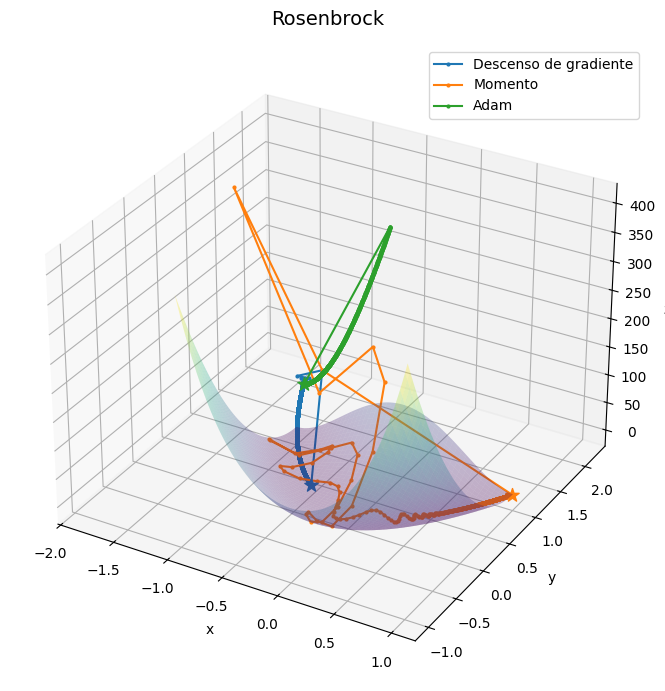

In [355]:
_, hist_gd   = gd(torch.tensor(puntos_iniciales, requires_grad=True, dtype=torch.float32), rosenbrock, lr=1e-3, verbose=False)
_, hist_gd_momentum   = gd_con_momento(torch.tensor(puntos_iniciales, requires_grad=True, dtype=torch.float32), rosenbrock, lr=1e-3, verbose=False)
_, hist_adam = adam(torch.tensor(puntos_iniciales, requires_grad=True, dtype=torch.float32), rosenbrock, lr=1e-3, verbose=False)

plot_trayectorias(
    funcion=rosenbrock,
    nombre_funcion="Rosenbrock",
    historiales=[hist_gd, hist_gd_momentum, hist_adam],
    nombres_optimizadores=["Descenso de gradiente", "Momento", "Adam"], 
    rango=(-1, 1)
)

Punto de partida: -0.3083529472351074, 0.42713695764541626
Pérdida 12.73786735534668 en época 1 en el punto (-0.34669235348701477, 0.36072587966918945)
Pérdida 7.599061489105225 en época 2 en el punto (-0.3773549795150757, 0.31261980533599854)
Pérdida 4.794694900512695 en época 3 en el punto (-0.40029406547546387, 0.27857518196105957)
Pérdida 3.361255168914795 en época 4 en el punto (-0.41644176840782166, 0.2549072206020355)
Pérdida 2.6702628135681152 en época 5 en el punto (-0.427182137966156, 0.23861052095890045)
Pérdida 2.351861000061035 en época 6 en el punto (-0.43391817808151245, 0.22738532721996307)
Pérdida 2.091125965118408 en época 11 en el punto (-0.4398326277732849, 0.2041873037815094)
Pérdida 2.0646603107452393 en época 16 en el punto (-0.4332793354988098, 0.19525209069252014)
Pérdida 2.0411250591278076 en época 21 en el punto (-0.4252578914165497, 0.1879526674747467)
Pérdida 2.017522096633911 en época 26 en el punto (-0.4169972240924835, 0.18089184165000916)
Pérdida 1.9938

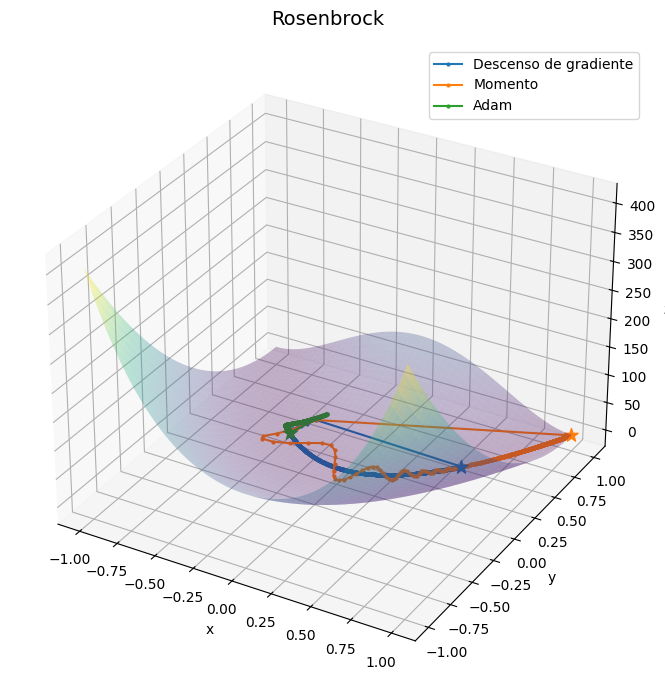

In [356]:
_, hist_gd   = gd(torch.tensor(puntos_iniciales2, requires_grad=True, dtype=torch.float32), rosenbrock, lr=1e-3)
_, hist_gd_momentum   = gd_con_momento(torch.tensor(puntos_iniciales2, requires_grad=True, dtype=torch.float32), rosenbrock, lr=1e-3)
_, hist_adam = adam(torch.tensor(puntos_iniciales2, requires_grad=True, dtype=torch.float32), rosenbrock, lr=1e-3)

plot_trayectorias(
    funcion=rosenbrock,
    nombre_funcion="Rosenbrock",
    historiales=[hist_gd, hist_gd_momentum, hist_adam],
    nombres_optimizadores=["Descenso de gradiente", "Momento", "Adam"], 
    rango=(-1, 1)
)

Punto de partida: -0.7165440917015076, 2.1838340759277344
Pérdida final 0.41672664880752563 en época 1000 en el punto (-0.42589402198791504, 0.5757918953895569)
Punto de partida: -0.7165440917015076, 2.1838340759277344
Pérdida final 5.534903441910927e-16 en época 1000 en el punto (-9.916075072169406e-09, 2.3939527693528362e-08)
Punto de partida: -0.7165440917015076, 2.1838340759277344
Pérdida final 0.5999321937561035 en época 1000 en el punto (-1.7813336849212646, 1.4325727224349976)


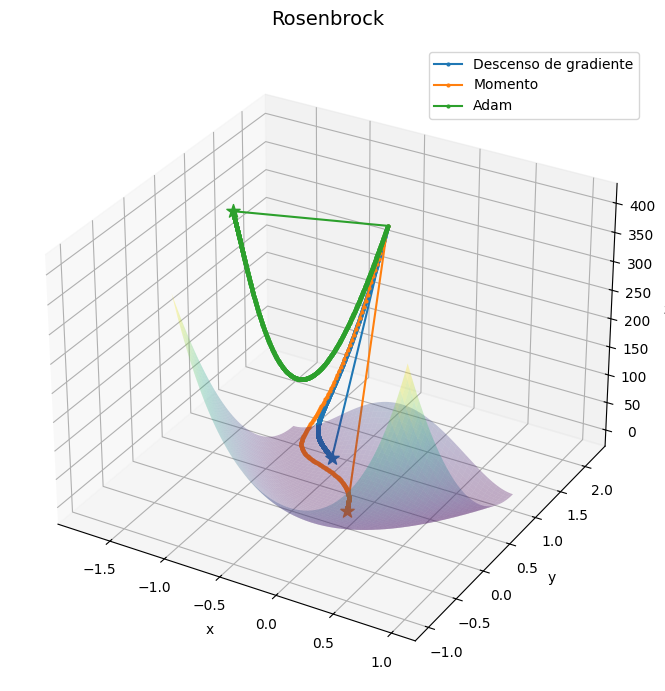

In [357]:
_, hist_gd   = gd(torch.tensor(puntos_iniciales, requires_grad=True, dtype=torch.float32), three_hump_camel, lr=1e-3, verbose=False)
_, hist_gd_momentum   = gd_con_momento(torch.tensor(puntos_iniciales, requires_grad=True, dtype=torch.float32), three_hump_camel, lr=1e-3, verbose=False)
_, hist_adam = adam(torch.tensor(puntos_iniciales, requires_grad=True, dtype=torch.float32), three_hump_camel, lr=1e-3, verbose=False)

plot_trayectorias(
    funcion=rosenbrock,
    nombre_funcion="Rosenbrock",
    historiales=[hist_gd, hist_gd_momentum, hist_adam],
    nombres_optimizadores=["Descenso de gradiente", "Momento", "Adam"], 
    rango=(-1, 1)
)

Punto de partida: -0.3083529472351074, 0.42713695764541626
Pérdida final 0.009075161069631577 en época 1000 en el punto (-0.042768776416778564, 0.09786217659711838)
Punto de partida: -0.3083529472351074, 0.42713695764541626
Pérdida final 4.827689511884568e-18 en época 1000 en el punto (-9.260929245691329e-10, 2.235785778736954e-09)
Punto de partida: -0.3083529472351074, 0.42713695764541626
Pérdida final 4.461323442228604e-06 en época 1000 en el punto (-0.0008903121924959123, 0.002176334848627448)


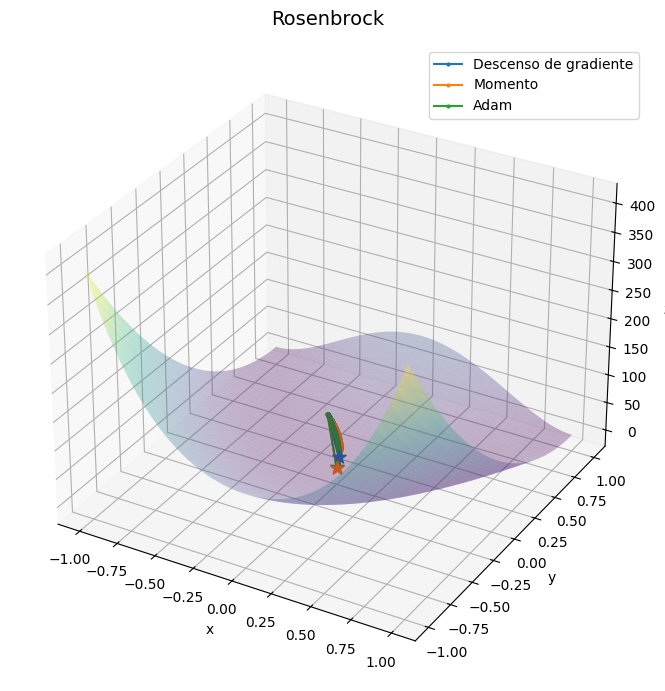

In [358]:
_, hist_gd   = gd(torch.tensor(puntos_iniciales2, requires_grad=True, dtype=torch.float32), three_hump_camel, lr=1e-3, verbose=False)
_, hist_gd_momentum   = gd_con_momento(torch.tensor(puntos_iniciales2, requires_grad=True, dtype=torch.float32), three_hump_camel, lr=1e-3, verbose=False)
_, hist_adam = adam(torch.tensor(puntos_iniciales2, requires_grad=True, dtype=torch.float32), three_hump_camel, lr=1e-3, verbose=False)

plot_trayectorias(
    funcion=rosenbrock,
    nombre_funcion="Rosenbrock",
    historiales=[hist_gd, hist_gd_momentum, hist_adam],
    nombres_optimizadores=["Descenso de gradiente", "Momento", "Adam"], 
    rango=(-1, 1)
)

Punto de partida: -0.7165440917015076, 2.1838340759277344
Pérdida final 0.007424177601933479 en época 1000 en el punto (0.9391953349113464, 3.060805320739746)
Punto de partida: -0.7165440917015076, 2.1838340759277344
Pérdida final 1.6825651982799172e-11 en época 1000 en el punto (0.9999972581863403, 3.0000030994415283)
Punto de partida: -0.7165440917015076, 2.1838340759277344
Pérdida final 4.286186218261719 en época 1000 en el punto (0.09574207663536072, 2.974479913711548)


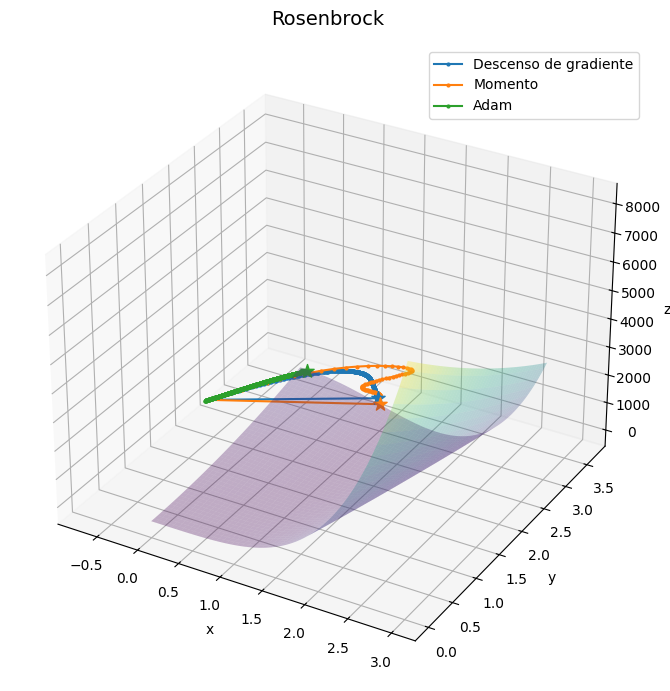

In [359]:
_, hist_gd   = gd(torch.tensor(puntos_iniciales, requires_grad=True, dtype=torch.float32), booth, lr=1e-3, verbose=False)
_, hist_gd_momentum   = gd_con_momento(torch.tensor(puntos_iniciales, requires_grad=True, dtype=torch.float32), booth, lr=1e-3, verbose=False)
_, hist_adam = adam(torch.tensor(puntos_iniciales, requires_grad=True, dtype=torch.float32), booth, lr=1e-3, verbose=False)

plot_trayectorias(
    funcion=rosenbrock,
    nombre_funcion="Rosenbrock",
    historiales=[hist_gd, hist_gd_momentum, hist_adam],
    nombres_optimizadores=["Descenso de gradiente", "Momento", "Adam"], 
    rango=(0, 3)
)

Punto de partida: -0.3083529472351074, 0.42713695764541626
Pérdida final 0.014643259346485138 en época 1000 en el punto (1.0853954553604126, 2.914605140686035)
Punto de partida: -0.3083529472351074, 0.42713695764541626
Pérdida final 1.6825651982799172e-11 en época 1000 en el punto (1.0000027418136597, 2.9999969005584717)
Punto de partida: -0.3083529472351074, 0.42713695764541626
Pérdida final 21.19479751586914 en época 1000 en el punto (0.5626428127288818, 1.309209942817688)


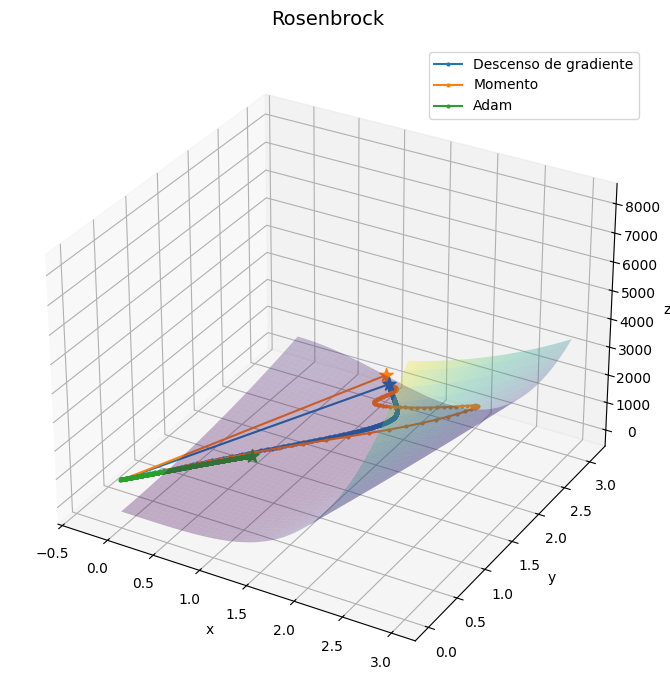

In [360]:
_, hist_gd   = gd(torch.tensor(puntos_iniciales2, requires_grad=True, dtype=torch.float32), booth, lr=1e-3, verbose=False)
_, hist_gd_momentum   = gd_con_momento(torch.tensor(puntos_iniciales2, requires_grad=True, dtype=torch.float32), booth, lr=1e-3, verbose=False)
_, hist_adam = adam(torch.tensor(puntos_iniciales2, requires_grad=True, dtype=torch.float32), booth, lr=1e-3, verbose=False)

plot_trayectorias(
    funcion=rosenbrock,
    nombre_funcion="Rosenbrock",
    historiales=[hist_gd, hist_gd_momentum, hist_adam],
    nombres_optimizadores=["Descenso de gradiente", "Momento", "Adam"], 
    rango=(0, 3)
)

Punto de partida: -0.7165440917015076, 2.1838340759277344
Pérdida final -64.19561767578125 en época 1000 en el punto (-2.9035308361053467, 2.7467987537384033)
Punto de partida: -0.7165440917015076, 2.1838340759277344
Pérdida final -64.19561767578125 en época 1000 en el punto (-2.903533935546875, 2.746802568435669)
Punto de partida: -0.7165440917015076, 2.1838340759277344
Pérdida final -50.37800598144531 en época 1000 en el punto (-1.810274362564087, 2.731621026992798)


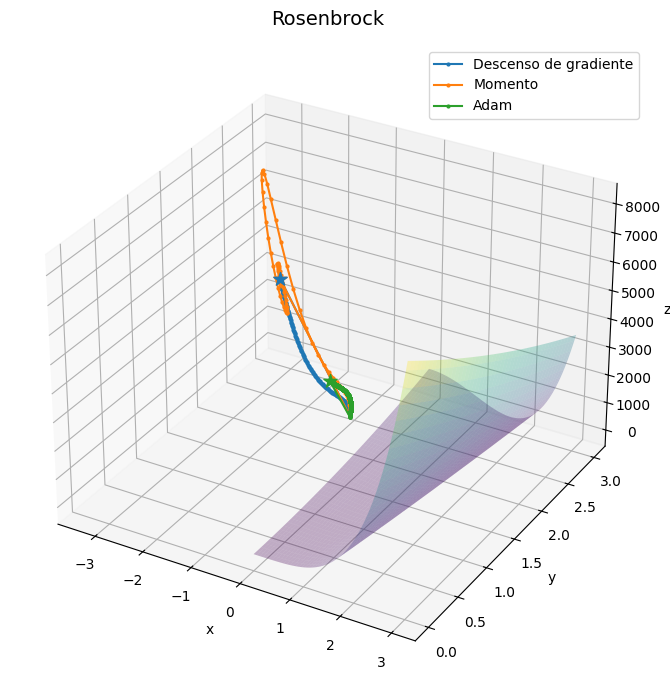

In [361]:
_, hist_gd   = gd(torch.tensor(puntos_iniciales, requires_grad=True, dtype=torch.float32), styblinski_tang, lr=1e-3, verbose=False)
_, hist_gd_momentum   = gd_con_momento(torch.tensor(puntos_iniciales, requires_grad=True, dtype=torch.float32), styblinski_tang, lr=1e-3, verbose=False)
_, hist_adam = adam(torch.tensor(puntos_iniciales, requires_grad=True, dtype=torch.float32), styblinski_tang, lr=1e-3, verbose=False)

plot_trayectorias(
    funcion=rosenbrock,
    nombre_funcion="Rosenbrock",
    historiales=[hist_gd, hist_gd_momentum, hist_adam],
    nombres_optimizadores=["Descenso de gradiente", "Momento", "Adam"], 
    rango=(0, 3)
)

Punto de partida: -0.3083529472351074, 0.42713695764541626
Pérdida final -64.19561767578125 en época 1000 en el punto (-2.9035308361053467, 2.7467987537384033)
Punto de partida: -0.3083529472351074, 0.42713695764541626
Pérdida final -64.19561767578125 en época 1000 en el punto (-2.903533935546875, 2.746802806854248)
Punto de partida: -0.3083529472351074, 0.42713695764541626
Pérdida final -34.19410705566406 en época 1000 en el punto (-1.5231934785842896, 1.6909124851226807)


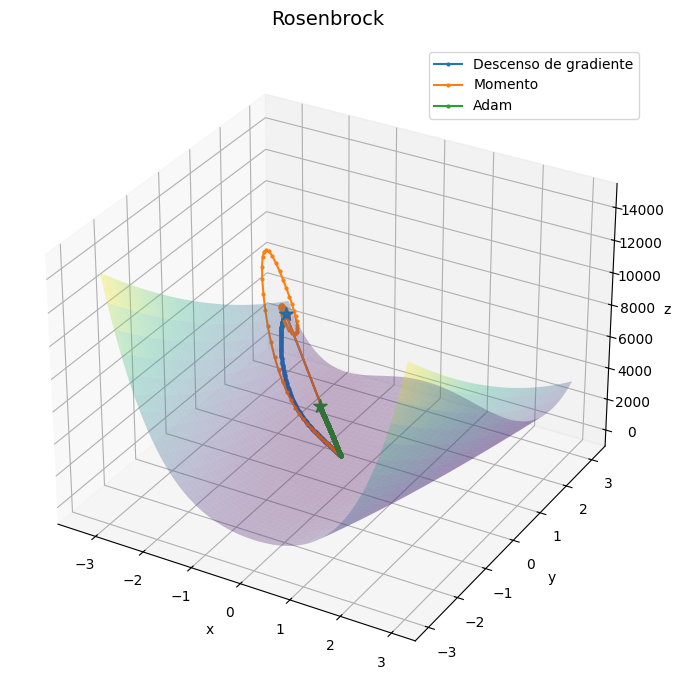

In [362]:
_, hist_gd   = gd(torch.tensor(puntos_iniciales2, requires_grad=True, dtype=torch.float32), styblinski_tang, lr=1e-3, verbose=False)
_, hist_gd_momentum   = gd_con_momento(torch.tensor(puntos_iniciales2, requires_grad=True, dtype=torch.float32), styblinski_tang, lr=1e-3, verbose=False)
_, hist_adam = adam(torch.tensor(puntos_iniciales2, requires_grad=True, dtype=torch.float32), styblinski_tang, lr=1e-3, verbose=False)

plot_trayectorias(
    funcion=rosenbrock,
    nombre_funcion="Rosenbrock",
    historiales=[hist_gd, hist_gd_momentum, hist_adam],
    nombres_optimizadores=["Descenso de gradiente", "Momento", "Adam"], 
    rango=(-3, 3)
)

# Comentarios Finales

De todos los métodos el peor, por mucho, fue el descenso de gradiente con momento. Estas funciones se utilizan para probar diferentes métodos optimizadores y por lo tanto están diseñadas para ser difíciles de optimizar, sin embargo los resultados parecen ser más o menos catastróficos en todos los casos.